<h1 id="tocheading">Table of Contents</h1>
<div id="toc"></div>

----

In [ ]:
!pip install watermark
!pip install segmentation-models
!pip install 'git+https://github.com/qubvel/segmentation_models'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.2 MB/s eta 0:00:00
  Cloning https://github.com/qubvel/segmentation_models to /tmp/pip-req-build-t1xdpgav
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models /tmp/pip-req-build-t1xdpgav


In [ ]:
from keras import backend as K
import tensorflow as tf
import numpy as np

In [ ]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,matplotlib,seaborn,scipy,skimage,PIL
# https://github.com/rasbt/watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.8.10
IPython version      : 7.9.0

numpy     : 1.21.6
pandas    : 1.3.5
matplotlib: 3.2.2
seaborn   : 0.11.2
scipy     : 1.7.3
skimage   : 0.18.3
PIL       : 7.1.2

Compiler    : GCC 9.4.0
OS          : Linux
Release     : 5.10.147+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [ ]:
import keras
keras.__version__

'2.11.0'

In [ ]:
tf.__version__

'2.11.0'

----

# Imports

In [ ]:
!ls

gdrive	sample_data


In [ ]:
from urllib.request import urlretrieve
from zipfile import ZipFile

In [ ]:
import matplotlib.pylab as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 8

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)

Mounted at /content/gdrive


In [ ]:
!ls

gdrive	sample_data


In [ ]:
%%time

ZipFile('//content/gdrive/MyDrive/Training.zip').extractall('/')
ZipFile('/content/gdrive/MyDrive/Testing.zip').extractall('/')

CPU times: user 196 ms, sys: 53.9 ms, total: 250 ms
Wall time: 272 ms


----

# Getting the data

In [ ]:
DATA_PATH = '/train/'
DATA_TEST_PATH = '/test/'

In [ ]:
import sys
import os
data_dir = os.listdir(DATA_PATH);data_dir


['mask', 'images', '1st_manual']

In [ ]:
x_train_path = DATA_PATH + 'images/'
y_mask_path = DATA_PATH  + 'mask/'
y_1st_manual_path = DATA_PATH  + '1st_manual/'

In [ ]:
x_test_path = DATA_PATH + 'images/'
y_1st_manual_path = DATA_PATH  + '1st_manual/'

In [ ]:
x_train_dir = sorted(os.listdir(x_train_path))
y_mask_dir = sorted(os.listdir(y_mask_path))
y_1st_manual_dir = sorted(os.listdir(y_1st_manual_path))

In [ ]:
x_test_dir = sorted(os.listdir(x_test_path))


In [ ]:
len(x_train_dir), len(y_mask_dir), len(y_1st_manual_dir)

(20, 20, 20)

In [ ]:
x_train_dir[:5], y_mask_dir[0:5]

(['21_training.tif',
  '22_training.tif',
  '23_training.tif',
  '24_training.tif',
  '25_training.tif'],
 ['21_training_mask.gif',
  '22_training_mask.gif',
  '23_training_mask.gif',
  '24_training_mask.gif',
  '25_training_mask.gif'])

----

# `io`: listing and loading images

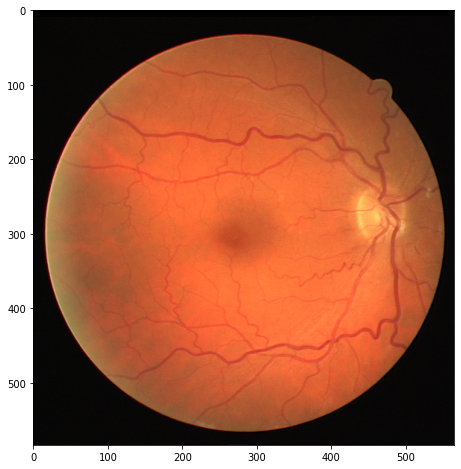

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img=mpimg.imread(x_train_path + x_train_dir[1])
imgplot = plt.imshow(img)

In [ ]:
x_train=[]
y_train=[]
for x in range(len(x_train_dir)):
      x_train.append(mpimg.imread(x_train_path + x_train_dir[x]))
      y_train.append(mpimg.imread(y_1st_manual_path + y_1st_manual_dir[x]))

In [ ]:
x_test=[]
for x in range(len(x_test_dir)):
      x_test.append(mpimg.imread(x_test_path + x_test_dir[x]))


In [ ]:
def _matching_datasets():

        x_t_name_root = [x.split('_')[0] for x in sorted(os.listdir(x_train_path))]
        print(x_t_name_root[0:100])
        y_t_name_root = [x.split('_')[0] for x in sorted(os.listdir(y_1st_manual_path))]
        print(y_t_name_root[0:100])
        return np.all(x_t_name_root == y_t_name_root)

assert _matching_datasets(), 'did not match'

['21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40']
['21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40']


In [ ]:
from tqdm import tqdm_notebook
from skimage.transform import resize

X_trainx = np.zeros((len(x_train), 544, 544, 3), dtype=np.uint8)
y_trainx = np.zeros((len(y_train), 544, 544, 1), dtype=np.bool)
sizes_test = []
for n, id_ in tqdm_notebook(enumerate(x_train), total=len(x_train)):
    sizes_test.append([id_.shape[0], id_.shape[1]])
    resized_array = resize(id_, (544, 544, 3), mode='reflect', preserve_range=True)
    X_trainx[n] = resized_array

<ipython-input-128-bbf7f564f642>:5: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y_trainx = np.zeros((len(y_train), 544, 544, 1), dtype=np.bool)
<ipython-input-128-bbf7f564f642>:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for n, id_ in tqdm_notebook(enumerate(x_train), total=len(x_train)):


  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
for n, id_ in tqdm_notebook(enumerate(y_train), total=len(y_train)):
        y_trainx[n] = resize(id_, (544, 544, 1), mode='reflect', preserve_range=True)

<ipython-input-129-ab23b2b5ff50>:1: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for n, id_ in tqdm_notebook(enumerate(y_train), total=len(y_train)):


  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
X_testx = np.zeros((len(x_test), 544, 544, 3), dtype=np.uint8)
sizes_test = []
for n, id_ in tqdm_notebook(enumerate(x_test), total=len(x_test)):
    sizes_test.append([id_.shape[0], id_.shape[1]])
    resized_array = resize(id_, (544, 544, 3), mode='reflect', preserve_range=True)
    X_testx[n] = resized_array

<ipython-input-130-efc57d56aa30>:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for n, id_ in tqdm_notebook(enumerate(x_test), total=len(x_test)):


  0%|          | 0/20 [00:00<?, ?it/s]

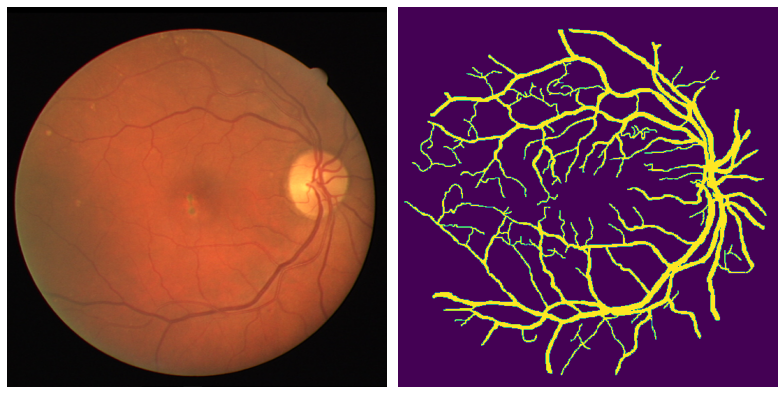

In [ ]:
fig = plt.figure(figsize=(11,11))
ax1 = fig.add_subplot(121); ax1.imshow(np.squeeze(X_trainx[4])); ax1.axis('off');
ax2 = fig.add_subplot(122); ax2.imshow(np.squeeze(y_trainx[4])); ax2.axis('off');
plt.tight_layout()

In [ ]:
X_trainx = np.asarray(X_trainx)/255.0
X_testx = np.asarray(X_testx)/255.0

y_trainx = np.asarray(y_trainx)


In [ ]:
X_trainx.max(), X_testx.max(), X_trainx.min(), X_testx.min(), y_trainx.max(), y_trainx.min()

(1.0, 1.0, 0.0, 0.0, True, False)

In [ ]:
from __future__ import division
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred = K.cast(y_pred, 'float32')
    y_pred_f = K.cast(K.greater(K.flatten(y_pred), 0.5), 'float32')
    intersection = y_true_f * y_pred_f
    score = 2. * K.sum(intersection) / (K.sum(y_true_f) + K.sum(y_pred_f))
    return score

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = y_true_f * y_pred_f
    score = (2. * K.sum(intersection) + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1. - score

def bce_dice_loss(y_true, y_pred):
    void_label = -1.
    y_pred = tf.reshape(y_pred, [-1])
    y_true = tf.reshape(y_true, [-1])
    idx = tf.where(tf.not_equal(y_true, tf.constant(void_label, dtype=tf.float32)))
    y_pred = tf.gather_nd(y_pred, idx)
    y_true = tf.gather_nd(y_true, idx)
    return loss(y_true, K.sigmoid(y_pred)) + dice_loss(y_true, K.sigmoid(y_pred))

def bce_logdice_loss(y_true, y_pred):
    void_label = -1.
    y_pred = tf.reshape(y_pred, [-1])
    y_true = tf.reshape(y_true, [-1])
    idx = tf.where(tf.not_equal(y_true, tf.constant(void_label, dtype=tf.float32)))
    y_pred = tf.gather_nd(y_pred, idx)
    y_true = tf.gather_nd(y_true, idx)
    return loss(y_true, y_pred) - K.log(1. - dice_loss(y_true, y_pred))

def weighted_bce_loss(y_true, y_pred, weight):
    epsilon = 1e-7
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
    logit_y_pred = K.log(y_pred / (1. - y_pred))
    loss = weight * (logit_y_pred * (1. - y_true) +
                     K.log(1. + K.exp(-K.abs(logit_y_pred))) + K.maximum(-logit_y_pred, 0.))
    return K.sum(loss) / K.sum(weight)

def weighted_dice_loss(y_true, y_pred, weight):
    smooth = 1.
    w, m1, m2 = weight, y_true, y_pred
    intersection = (m1 * m2)
    score = (2. * K.sum(w * intersection) + smooth) / (K.sum(w * m1) + K.sum(w * m2) + smooth)
    loss = 1. - K.sum(score)
    return loss

def weighted_bce_dice_loss(y_true, y_pred):

    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    # if we want to get same size of output, kernel size must be odd
    averaged_mask = K.pool2d(
            y_true, pool_size=(50, 50), strides=(1, 1), padding='same', pool_mode='avg')
    weight = K.ones_like(averaged_mask)
    w0 = K.sum(weight)
    weight = 5. * K.exp(-5. * K.abs(averaged_mask - 0.5))
    w1 = K.sum(weight)
    weight *= (w0 / w1)
    loss = weighted_bce_loss(y_true, y_pred, weight) + dice_loss(y_true, y_pred)
    return loss


"""
Lovasz-Softmax and Jaccard hinge loss in Tensorflow
Maxim Berman 2018 ESAT-PSI KU Leuven (MIT License)
"""



def lovasz_grad(gt_sorted):
    """
    Computes gradient of the Lovasz extension w.r.t sorted errors
    See Alg. 1 in paper
    """
    gts = tf.reduce_sum(gt_sorted)
    intersection = gts - tf.cumsum(gt_sorted)
    union = gts + tf.cumsum(1. - gt_sorted)
    jaccard = 1. - intersection / union
    jaccard = tf.concat((jaccard[0:1], jaccard[1:] - jaccard[:-1]), 0)
    return jaccard


# --------------------------- BINARY LOSSES ---------------------------


def lovasz_hinge(logits, labels, per_image=True, ignore=None):
    """
    Binary Lovasz hinge loss
      logits: [B, H, W] Variable, logits at each pixel (between -\infty and +\infty)
      labels: [B, H, W] Tensor, binary ground truth masks (0 or 1)
      per_image: compute the loss per image instead of per batch
      ignore: void class id
    """
    if per_image:
        def treat_image(log_lab):
            log, lab = log_lab
            log, lab = tf.expand_dims(log, 0), tf.expand_dims(lab, 0)
            log, lab = flatten_binary_scores(log, lab, ignore)
            return lovasz_hinge_flat(log, lab)
        losses = tf.map_fn(treat_image, (logits, labels), dtype=tf.float32)
        loss = tf.reduce_mean(losses)
    else:
        loss = lovasz_hinge_flat(*flatten_binary_scores(logits, labels, ignore))
    return loss


def lovasz_hinge_flat(logits, labels):
    """
    Binary Lovasz hinge loss
      logits: [P] Variable, logits at each prediction (between -\infty and +\infty)
      labels: [P] Tensor, binary ground truth labels (0 or 1)
      ignore: label to ignore
    """

    def compute_loss():
        labelsf = tf.cast(labels, logits.dtype)
        signs = 2. * labelsf - 1.
        errors = 1. - logits * tf.stop_gradient(signs)
        errors_sorted, perm = tf.nn.top_k(errors, k=tf.shape(errors)[0], name="descending_sort")
        gt_sorted = tf.gather(labelsf, perm)
        grad = lovasz_grad(gt_sorted)
        loss = tf.tensordot(tf.nn.relu(errors_sorted), tf.stop_gradient(grad), 1, name="loss_non_void")
        return loss

    # deal with the void prediction case (only void pixels)
    loss = tf.cond(tf.equal(tf.shape(logits)[0], 0),
                   lambda: tf.reduce_sum(logits) * 0.,
                   compute_loss,
                   strict=True,
                   name="loss"
                   )
    return loss


def flatten_binary_scores(scores, labels, ignore=None):
    """
    Flattens predictions in the batch (binary case)
    Remove labels equal to 'ignore'
    """
    scores = tf.reshape(scores, (-1,))
    labels = tf.reshape(labels, (-1,))
    if ignore is None:
        return scores, labels
    valid = tf.not_equal(labels, ignore)
    vscores = tf.boolean_mask(scores, valid, name='valid_scores')
    vlabels = tf.boolean_mask(labels, valid, name='valid_labels')
    return vscores, vlabels


# --------------------------- MULTICLASS LOSSES ---------------------------


def lovasz_softmax(probas, labels, classes='all', per_image=False, ignore=None, order='BHWC'):
    """
    Multi-class Lovasz-Softmax loss
      probas: [B, H, W, C] or [B, C, H, W] Variable, class probabilities at each prediction (between 0 and 1)
      labels: [B, H, W] Tensor, ground truth labels (between 0 and C - 1)
      classes: 'all' for all, 'present' for classes present in labels, or a list of classes to average.
      per_image: compute the loss per image instead of per batch
      ignore: void class labels
      order: use BHWC or BCHW
    """
    if per_image:
        def treat_image(prob_lab):
            prob, lab = prob_lab
            prob, lab = tf.expand_dims(prob, 0), tf.expand_dims(lab, 0)
            prob, lab = flatten_probas(prob, lab, ignore, order)
            return lovasz_softmax_flat(prob, lab, classes=classes)
        losses = tf.map_fn(treat_image, (probas, labels), dtype=tf.float32)
        loss = tf.reduce_mean(losses)
    else:
        loss = lovasz_softmax_flat(*flatten_probas(probas, labels, ignore, order), classes=classes)
    return loss

def mean_iou(y_true, y_pred):
    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        y_pred_ = tf.to_int32(y_pred > t)
        score, up_opt = tf.metrics.mean_iou(y_true, y_pred_, 2)
        K.get_session().run(tf.local_variables_initializer())
        with tf.control_dependencies([up_opt]):
            score = tf.identity(score)
        prec.append(score)
    return K.mean(K.stack(prec), axis=0)

def lovasz_softmax_flat(probas, labels, classes='all'):
    """
    Multi-class Lovasz-Softmax loss
      probas: [P, C] Variable, class probabilities at each prediction (between 0 and 1)
      labels: [P] Tensor, ground truth labels (between 0 and C - 1)
      classes: 'all' for all, 'present' for classes present in labels, or a list of classes to average.
    """
    C = 1
    losses = []
    present = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = tf.cast(tf.equal(labels, c), probas.dtype)  # foreground for class c
        if classes == 'present':
            present.append(tf.reduce_sum(fg) > 0)
        errors = tf.abs(fg - probas[:, c])
        errors_sorted, perm = tf.nn.top_k(errors, k=tf.shape(errors)[0], name="descending_sort_{}".format(c))
        fg_sorted = tf.gather(fg, perm)
        grad = lovasz_grad(fg_sorted)
        losses.append(
            tf.tensordot(errors_sorted, tf.stop_gradient(grad), 1, name="loss_class_{}".format(c))
                      )
    if len(class_to_sum) == 1:  # short-circuit mean when only one class
        return losses[0]
    losses_tensor = tf.stack(losses)
    if classes == 'present':
        present = tf.stack(present)
        losses_tensor = tf.boolean_mask(losses_tensor, present)
    loss = tf.reduce_mean(losses_tensor)
    return loss


def flatten_probas(probas, labels, ignore=None, order='BHWC'):
    """
    Flattens predictions in the batch
    """
    if order == 'BCHW':
        probas = tf.transpose(probas, (0, 2, 3, 1), name="BCHW_to_BHWC")
        order = 'BHWC'
    if order != 'BHWC':
        raise NotImplementedError('Order {} unknown'.format(order))
    C = 1
    probas = tf.reshape(probas, (-1, C))
    labels = tf.reshape(labels, (-1,))
    if ignore is None:
        return probas, labels
    valid = tf.not_equal(labels, ignore)
    vprobas = tf.boolean_mask(probas, valid, name='valid_probas')
    vlabels = tf.boolean_mask(labels, valid, name='valid_labels')
    return vprobas, vlabels

def keras_lovasz_softmax(labels,probas):
    #return lovasz_softmax(probas, labels)+binary_crossentropy(labels, probas)
    return lovasz_softmax(probas, labels)

def keras_lovasz_hinge(labels,logits):
    return lovasz_hinge(logits, labels, per_image=True, ignore=None)


def focal_loss(y_true, y_pred):
    gamma=0.75
    alpha=0.25
    pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
    pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))

    pt_1 = K.clip(pt_1, 1e-3, .999)
    pt_0 = K.clip(pt_0, 1e-3, .999)

    return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))-K.sum((1-alpha) * K.pow( pt_0, gamma) * K.log(1. - pt_0))

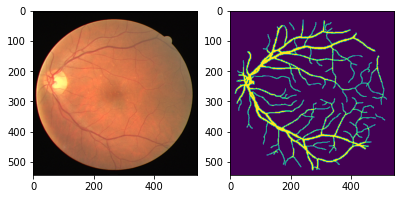

0


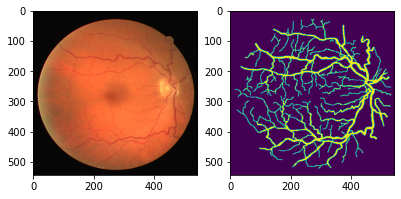

1


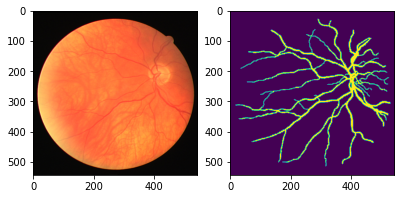

2


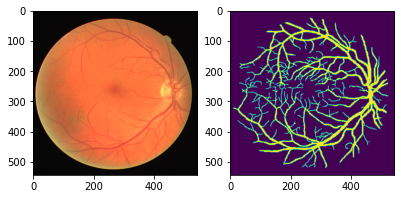

3


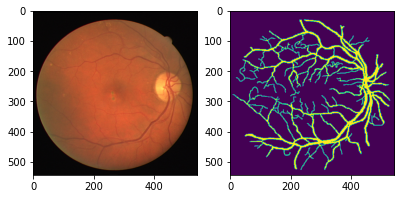

4


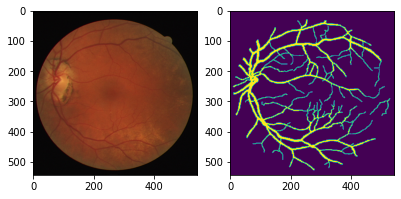

5


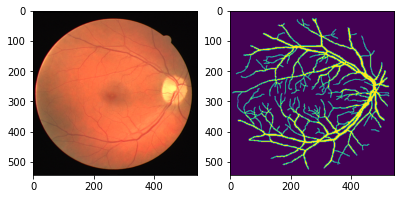

6


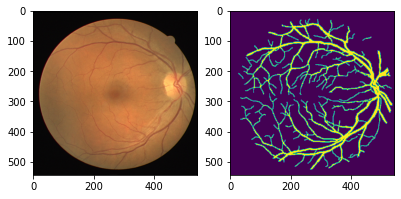

7


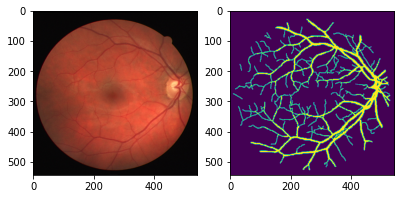

8


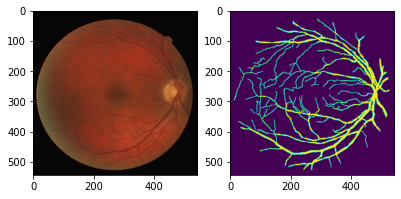

9


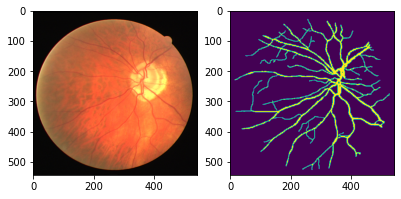

10


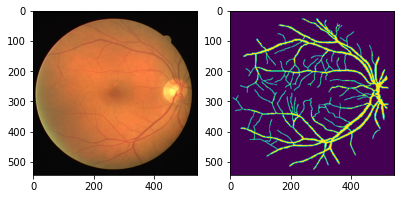

11


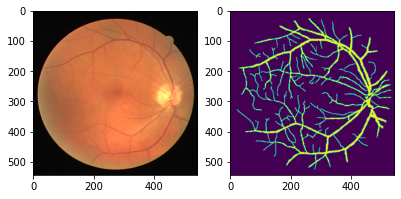

12


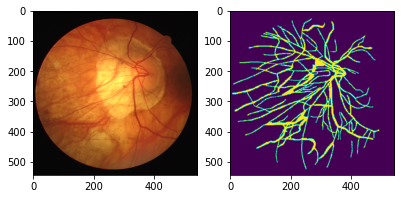

13


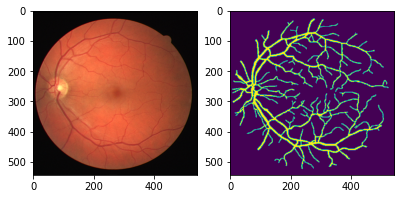

14


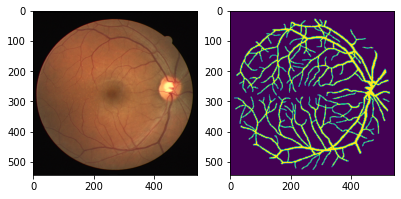

15


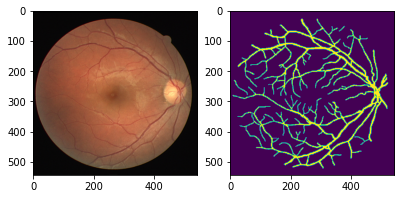

16


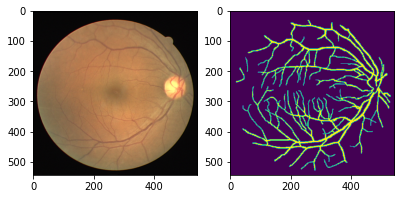

17


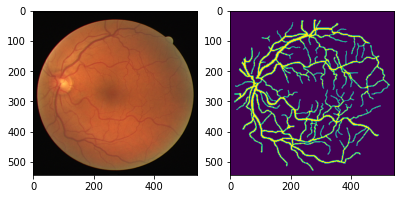

18


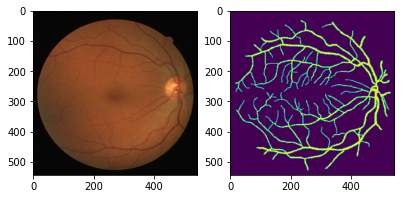

19


In [ ]:
for ix in range((len(X_trainx))):
    fig = plt.figure()
    fig.add_subplot(1, 3, 1)
    plt.imshow((X_trainx[ix]))

    fig.add_subplot(1, 3, 2)
    plt.imshow(np.squeeze(y_trainx[ix]))


    plt.show()
    print(ix)

In [ ]:
x_train = X_trainx
y_train = y_trainx
x_test = X_testx

In [ ]:
np.asarray(x_train[1]).shape, np.asarray(y_train[1]).shape

((544, 544, 3), (544, 544, 1))

In [ ]:
# !git clone https://github.com/qubvel/segmentation_models
# !git clone https://github.com/qubvel/efficientnet
# !git clone https://github.com/qubvel/classification_models

In [ ]:
!ls

gdrive	sample_data


In [ ]:
print(sys.path)

['/content', '/env/python', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '', '/usr/local/lib/python3.8/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.8/dist-packages/IPython/extensions', '/root/.ipython']


In [ ]:
y_train = np.squeeze(y_train)
x_train = np.squeeze(x_train)

In [ ]:
y_train=np.expand_dims(y_train, axis=-1)


In [ ]:
x_valid = x_train[17:20]
y_valid = y_train[17:20]
x_train = x_train[0:17]
y_train = y_train[0:17]

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
data_gen_args = dict(horizontal_flip=True,
                     vertical_flip=True,
                    rotation_range=90,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    zoom_range=0.2,
 #                   shear_range=0.05,
 #                  brightness_range=[0.1,0.7],
                    fill_mode='nearest')


data_val_args = dict(horizontal_flip=True)

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

img_valid_datagen = ImageDataGenerator(**data_val_args)
mask_valid_datagen = ImageDataGenerator(**data_val_args)

seed = 2019
bs = 4

image_generator = image_datagen.flow(x_train, seed=seed, batch_size=bs, shuffle=True)
mask_generator = mask_datagen.flow(y_train, seed=seed, batch_size=bs, shuffle=True)

# Just zip the two generators to get a generator that provides augmented images and masks at the same time
train_generator = zip(image_generator, mask_generator)

img_valid_generator = img_valid_datagen.flow(x_valid, seed=seed, batch_size=bs, shuffle=True)
mask_valid_generator = mask_valid_datagen.flow(y_valid, seed=seed, batch_size=bs, shuffle=True)

valid_generator = zip(img_valid_generator, mask_valid_generator)


In [ ]:
import random
def random_crop(img, mask, width, height):
    assert img.shape[0] >= height
    assert img.shape[1] >= width
    assert img.shape[0] == mask.shape[0]
    assert img.shape[1] == mask.shape[1]
    x = random.randint(0, img.shape[1] - width)
    y = random.randint(0, img.shape[0] - height)
    img = img[y:y+height, x:x+width]
    mask = mask[y:y+height, x:x+width]
    img = np.expand_dims(img, axis = 0)
    mask = np.expand_dims(mask, axis = 0)
    return img, mask


def crop_generator(batches, crop_length):
    """Take as input a Keras ImageGen (Iterator) and generate random
    crops from the image batches generated by the original iterator.
    """
    while True:
        batch_x, batch_y = next(batches)
        batch_crops = np.zeros((batch_x.shape[0], crop_length, crop_length, 3))
        for i in range(batch_x.shape[0]):
            batch_crops_x, batch_crops_y = random_crop(batch_x[i], batch_y[i], crop_length, crop_length)

        yield (batch_crops_x, batch_crops_y)

In [ ]:
train_crops = crop_generator(train_generator, 256)
valid_crops = crop_generator(valid_generator, 256)


In [ ]:
x_train.shape, y_train.shape

((17, 544, 544, 3), (17, 544, 544, 1))

In [ ]:
def matthews_correlation(y_true, y_pred):
    y_pred_pos = K.round(K.clip(y_pred, 0, 1))
    y_pred_neg = 1 - y_pred_pos

    y_pos = K.round(K.clip(y_true, 0, 1))
    y_neg = 1 - y_pos

    tp = K.sum(y_pos * y_pred_pos)
    tn = K.sum(y_neg * y_pred_neg)

    fp = K.sum(y_neg * y_pred_pos)
    fn = K.sum(y_pos * y_pred_neg)

    numerator = (tp * tn - fp * fn)
    denominator = K.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

    return numerator / (denominator + K.epsilon())

In [ ]:
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras import backend as K

In [ ]:
#convolutional block
def conv_block(x, kernelsize, filters, dropout, batchnorm=False):
    conv = layers.Conv2D(filters, (kernelsize, kernelsize), kernel_initializer='he_normal', padding="same")(x)
    if batchnorm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)
    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)
    conv = layers.Conv2D(filters, (kernelsize, kernelsize), kernel_initializer='he_normal', padding="same")(conv)
    if batchnorm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)
    return conv


In [ ]:

#Simple U-NET
def unetmodel(input_shape, dropout=0.2, batchnorm=True):

    filters = [16, 32, 64, 128, 256]
    kernelsize = 3
    upsample_size = 2

    inputs = layers.Input(input_shape)

    # Downsampling layers
    dn_1 = conv_block(inputs, kernelsize, filters[0], dropout, batchnorm)
    pool_1 = layers.MaxPooling2D(pool_size=(2,2))(dn_1)

    dn_2 = conv_block(pool_1, kernelsize, filters[1], dropout, batchnorm)
    pool_2 = layers.MaxPooling2D(pool_size=(2,2))(dn_2)

    dn_3 = conv_block(pool_2, kernelsize, filters[2], dropout, batchnorm)
    pool_3 = layers.MaxPooling2D(pool_size=(2,2))(dn_3)

    dn_4 = conv_block(pool_3, kernelsize, filters[3], dropout, batchnorm)
    pool_4 = layers.MaxPooling2D(pool_size=(2,2))(dn_4)

    dn_5 = conv_block(pool_4, kernelsize, filters[4], dropout, batchnorm)

    # Upsampling layers
    up_5 = layers.UpSampling2D(size=(upsample_size, upsample_size), data_format="channels_last")(dn_5)
    up_5 = layers.concatenate([up_5, dn_4], axis=3)
    up_conv_5 = conv_block(up_5, kernelsize, filters[3], dropout, batchnorm)

    up_4 = layers.UpSampling2D(size=(upsample_size, upsample_size), data_format="channels_last")(up_conv_5)
    up_4 = layers.concatenate([up_4, dn_3], axis=3)
    up_conv_4 = conv_block(up_4, kernelsize, filters[2], dropout, batchnorm)

    up_3 = layers.UpSampling2D(size=(upsample_size, upsample_size), data_format="channels_last")(up_conv_4)
    up_3 = layers.concatenate([up_3, dn_2], axis=3)
    up_conv_3 = conv_block(up_3, kernelsize, filters[1], dropout, batchnorm)

    up_2 = layers.UpSampling2D(size=(upsample_size, upsample_size), data_format="channels_last")(up_conv_3)
    up_2 = layers.concatenate([up_2, dn_1], axis=3)
    up_conv_2 = conv_block(up_2, kernelsize, filters[0], dropout, batchnorm)

    conv_final = layers.Conv2D(1, kernel_size=(1,1))(up_conv_2)
    conv_final = layers.BatchNormalization(axis=3)(conv_final)
    outputs = layers.Activation('sigmoid')(conv_final)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    model.summary()
    return model

In [ ]:
!pip install -U segmentation-models==0.2.1

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 KB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 KB 5.8 MB/s eta 0:00:00
  Attempting uninstall: image-classifiers
    Found existing installation: image-classifiers 1.0.0
    Uninstalling image-classifiers-1.0.0:
      Successfully uninstalled image-classifiers-1.0.0
  Attempting uninstall: segmentation-models
    Found existing installation: segmentation-models 1.0.1
    Uninstalling segmentation-models-1.0.1:
      Successfully uninstalled segmentation-models-1.0.1


In [ ]:
!pip uninstall segmentation_models


Found existing installation: segmentation-models 1.0.1
Uninstalling segmentation-models-1.0.1:
  Would remove:
    /usr/local/lib/python3.8/dist-packages/segmentation_models-1.0.1.dist-info/*
    /usr/local/lib/python3.8/dist-packages/segmentation_models/*
Proceed (Y/n)? y
  Successfully uninstalled segmentation-models-1.0.1


In [ ]:
!pip install segmentation_models

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Using cached segmentation_models-1.0.1-py3-none-any.whl (33 kB)


In [ ]:
import segmentation_models as sm

BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

# load your data
x_train, y_train, x_val, y_val = load_data(...)

# preprocess input
x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)

# define model
model = sm.Unet(BACKBONE, encoder_weights='imagenet')
model.compile(
    'Adam',
    loss=sm.losses.bce_jaccard_loss,
    metrics=[sm.metrics.iou_score],
)

# fit model
# if you use data generator use model.fit_generator(...) instead of model.fit(...)
# more about `fit_generator` here: https://keras.io/models/sequential/#fit_generator
model.fit(
   x=x_train,
   y=y_train,
   batch_size=16,
   epochs=100,
   validation_data=(x_val, y_val),
)

AttributeError: ignored

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from segmentation_models import Unet


def model_train():


    model = Unet('efficientnetb3', encoder_weights='imagenet')
    model.compile(optimizer ='adam', loss= dice_loss , metrics = [dice_coef, matthews_correlation])
    #model.summary()

    return model

AttributeError: ignored

In [ ]:
X_trainx.max(), X_testx.max(), X_trainx.min(), X_testx.min(), y_trainx.max(), y_trainx.min()

(1.0, 1.0, 0.0, 0.0, True, False)

In [ ]:
from tensorflow.keras.applications import VGG16

# create VGG16 model without top layers
encoder = VGG16(weights='imagenet', include_top=False, input_shape=(544, 544, 3))

# import encoder weights
encoder.load_weights('imagenet')



NotFoundError: ignored

In [ ]:
earlystopper = EarlyStopping(patience=10, verbose=0, monitor='val_loss')
checkpointer = ModelCheckpoint('model-unet.h5', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5, min_lr=0.00001, verbose=1)

model = model_train()

TypeError: ignored

In [ ]:
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['matthews_correlation'])
plt.plot(history.history['val_matthews_correlation'])
plt.title('model matthews_correlation')
plt.ylabel('matthews_correlation')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

NameError: ignored

In [ ]:
def advanced_shifted_crop(image, grid_x=101, grid_y=101, grid_shift_ratio = 1):
    global rangex, rangey

    sizes_of_image = image.shape

    row_im_size, col_im_size = sizes_of_image[0], sizes_of_image[1]

    rangex = int((row_im_size-grid_x)/(grid_x/grid_shift_ratio)) + 1
    rangey = int((col_im_size-grid_y)/(grid_y/grid_shift_ratio)) + 1
#     rangex = int(row_im_size/(grid_x))
#     rangey = int(col_im_size/(grid_y))
#     rangez = int(time_size/(grid_z))
    zero_array = []
    for y in range(rangey):
        for x in range(rangex):
            # bbox = (x*grid_x, y*grid_y, z*grid_z, x*grid_x + grid_x, y*grid_y + grid_y, z*grid_z + grid_z)
            zero_array.append(image[int(x*grid_x/grid_shift_ratio):int((x*grid_x/grid_shift_ratio + grid_x)),
                                     int(y*grid_y/grid_shift_ratio):int((y*grid_y/grid_shift_ratio + grid_y))])

    return zero_array, rangex, rangey

In [ ]:
def repack_intersection(image_array, size_tuple, grid_x = 256, grid_y = 256, grid_shift_ratio = 101):

    size_of_image = np.asarray(image_array).shape
    length, size_x, size_y  = size_of_image[0], size_of_image[1], size_of_image[2]
    zero_array = np.zeros((size_tuple), dtype='float')
    index = 0
    for y in range(rangey):
        for x in range(rangex):
            # bbox = (x*grid_x, y*grid_y, z*grid_z, x*grid_x + grid_x, y*grid_y + grid_y, z*grid_z + grid_z)
            zero_array[int(x*grid_x/grid_shift_ratio):int((x*grid_x/grid_shift_ratio + grid_x)),
                       int(y*grid_y/grid_shift_ratio):int((y*grid_y/grid_shift_ratio + grid_y))] = zero_array[int(x*grid_x/grid_shift_ratio):int((x*grid_x/grid_shift_ratio + grid_x)),
                       int(y*grid_y/grid_shift_ratio):int((y*grid_y/grid_shift_ratio + grid_y))] + image_array[index, :, :]

            index = index+1

    return zero_array

In [ ]:
lenght, x_dim, y_dim, _ = np.asarray(x_test).shape
size_tuple = (x_dim, y_dim)
ones_array = np.ones(size_tuple);  np.asarray(x_test).shape, np.asarray(ones_array).shape


((20, 544, 544, 3), (544, 544))

In [ ]:
from tqdm import tqdm

cropped_ones_array, range_x, range_y = advanced_shifted_crop(ones_array, 256, 256, grid_shift_ratio = 8)
print(np.asarray(cropped_ones_array).shape)
repacked_ones_array = repack_intersection(np.asarray(cropped_ones_array), size_tuple, grid_x=256, grid_y=256, grid_shift_ratio = 8)

(100, 256, 256)


In [ ]:
preds_test = []

for x in tqdm(x_test):
    cropped_slice_array, range_x, range_y = advanced_shifted_crop(x, 256, 256, grid_shift_ratio = 8)
    preds_test_array = model.predict(np.asarray(cropped_slice_array),  verbose=1)
    preds_test_array = np.squeeze(preds_test_array)
    repacked_image = repack_intersection(preds_test_array, size_tuple, 256, 256, grid_shift_ratio = 8)
    test_output = repacked_image/repacked_ones_array
    preds_test.append(test_output)





  0%|          | 0/20 [00:00<?, ?it/s]


ValueError: ignored

In [ ]:
preds_train = []
for x in tqdm(x_valid):
    cropped_slice_array, range_x, range_y = advanced_shifted_crop(x, 256, 256, grid_shift_ratio = 8)
    preds_train_array = model.predict(np.asarray(cropped_slice_array),  verbose=1)
    preds_train_array = np.squeeze(preds_train_array)
    repacked_image = repack_intersection(preds_train_array, size_tuple, 256, 256, grid_shift_ratio = 8)
    train_output = repacked_image/repacked_ones_array
    preds_train.append(train_output)
print('done')

  0%|          | 0/3 [00:00<?, ?it/s]


ValueError: ignored

In [ ]:
preds_test_t = (np.asarray(preds_test) > 0.5).astype(np.uint8)
preds_train_t = (np.asarray(preds_train) > 0.5).astype(np.uint8)

IndexError: ignored

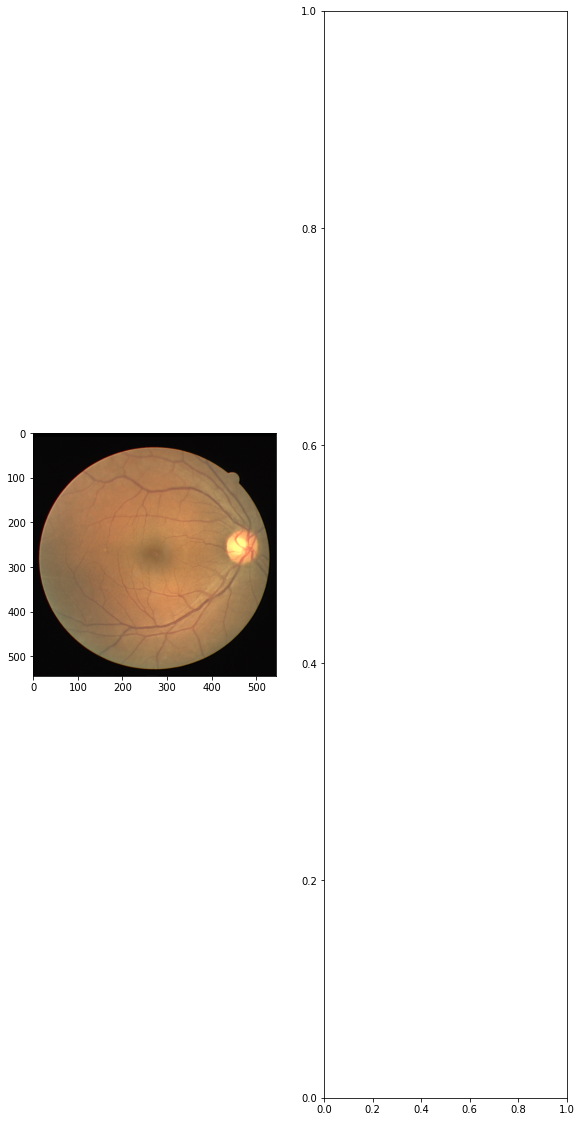

In [ ]:
for ix in range(0, int(len(x_valid))):

    fig = plt.figure(figsize=(20, 20))
    fig.add_subplot(1, 4, 1)
    plt.imshow(np.squeeze(x_valid[ix]))

    fig.add_subplot(1, 4, 2)
    plt.imshow(np.squeeze(preds_train[ix]))

    fig.add_subplot(1, 4, 3)
    plt.imshow(np.squeeze(preds_train_t[ix]))

    fig.add_subplot(1, 4, 4)
    plt.imshow(np.squeeze(y_valid[ix]))

    plt.show()

    print(ix)

In [ ]:
y_valid_t = (np.asarray(y_valid) > 0)*2
preds_train_tt = preds_train_t
new_visualisation = preds_train_tt + np.squeeze(y_valid_t)
for ix in range(0, int(len(y_valid_t))):

    fig = plt.figure(figsize=(20, 20))
    fig.add_subplot(1, 2, 1)
    plt.imshow(np.squeeze(new_visualisation[ix]))

    fig.add_subplot(1, 2, 2)
    plt.imshow(np.squeeze(y_valid[ix]))

    plt.show()

    print(ix)

ValueError: ignored

IndexError: ignored

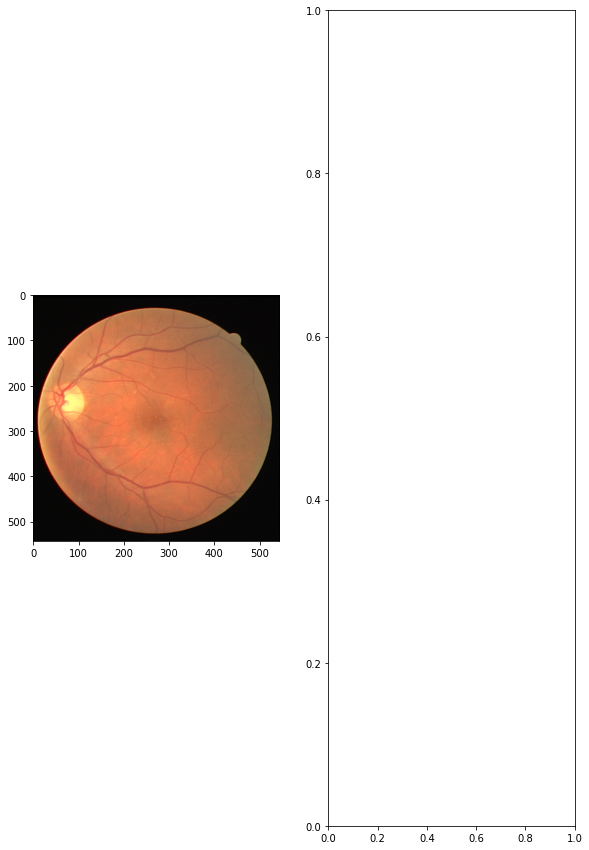

In [ ]:
for ix in range(0, int(len(x_test))):

    fig = plt.figure(figsize=(15, 15))
    fig.add_subplot(1, 3, 1)
    plt.imshow(np.squeeze(x_test[ix]))

    fig.add_subplot(1, 3, 2)
    plt.imshow(np.squeeze(preds_test[ix]))

    fig.add_subplot(1, 3, 3)
    plt.imshow(np.squeeze(preds_test_t[ix]))

    plt.show()

    print(ix)